# Purpose

## Group Florida counties into housing market segments based on growth, volatility, and migration patterns.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from pathlib import Path

# Project Paths

In [2]:
# Project root directory
PROJECT_ROOT = Path().resolve().parent

# Data paths
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Output paths
VISUALS = PROJECT_ROOT / "visuals"

# Load Data

In [3]:
df = pd.read_csv(DATA_PROCESSED / "merged_fl_county_year_features.csv")
df.head(10)

,fips,RegionName,year,zhvi_annual,STNAME,CTYNAME,domestic_mig,population,rdomestic_mig,yoy_growth,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility
0,12001,Alachua County,2020,213860.291033,Florida,Alachua County,1315,279765,NaN,NaN,0.319704,-0.125115,0.064152
1,12001,Alachua County,2021,244364.099887,Florida,Alachua County,1142,281710,4.067857,0.142634,0.319704,-0.125115,0.064152
2,12001,Alachua County,2022,282232.292655,Florida,Alachua County,1268,285241,4.473050,0.154966,0.319704,-0.125115,0.064152
3,12001,Alachua County,2023,295677.948240,Florida,Alachua County,408,288962,1.421100,0.047640,0.319704,-0.125115,0.064152
4,12001,Alachua County,2024,304504.265219,Florida,Alachua County,-1141,291782,-3.929442,0.029851,0.319704,-0.125115,0.064152
5,12003,Baker County,2020,214588.831681,Florida,Baker County,-141,28122,NaN,NaN,0.369415,-0.153888,0.094209
6,12003,Baker County,2021,250077.267178,Florida,Baker County,216,28378,7.646018,0.165379,0.369415,-0.153888,0.094209
7,12003,Baker County,2022,293861.137166,Florida,Baker County,-657,27781,-23.397853,0.175081,0.369415,-0.153888,0.094209
8,12003,Baker County,2023,292472.265114,Florida,Baker County,673,28542,23.897875,-0.004726,0.369415,-0.153888,0.094209
9,12003,Baker County,2024,298670.668188,Florida,Baker County,709,29325,24.504467,0.021193,0.369415,-0.153888,0.094209


In [4]:
df.columns

Index(['fips', 'RegionName', 'year', 'zhvi_annual', 'STNAME', 'CTYNAME',
       'domestic_mig', 'population', 'rdomestic_mig', 'yoy_growth',
       'boom_growth_2020_2022', 'cooling_delta_2024_vs_2022',
       'yoy_volatility'],
      dtype='object')

# Clustering Prep

In [5]:
# Get averages of each feature, per county
county_features = (
    df.groupby(["fips", "CTYNAME"])
    .agg({
        "boom_growth_2020_2022": "mean",
        "cooling_delta_2024_vs_2022": "mean",
        "yoy_volatility": "mean",
        "rdomestic_mig": "mean"
    })
    .reset_index() # Converts FIPS back to column instead of index (default)
)

In [6]:
county_features.head()

,fips,CTYNAME,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility,rdomestic_mig
0,12001,Alachua County,0.319704,-0.125115,0.064152,1.508141
1,12003,Baker County,0.369415,-0.153888,0.094209,8.162627
2,12005,Bay County,0.426789,-0.239428,0.108733,27.610062
3,12007,Bradford County,0.428973,-0.181912,0.090090,0.795386
4,12009,Brevard County,0.455545,-0.228420,0.111754,21.448371


In [7]:
county_features.shape

(67, 6)

# Select Clustering Features

In [8]:
# List column names from new dataframe
features = ["boom_growth_2020_2022","cooling_delta_2024_vs_2022","yoy_volatility","rdomestic_mig"]

In [9]:
# X is the feature matrix used for clustering
X = county_features[features].copy()

In [10]:
# Sanity check for missing values
print(X.isna().sum())

boom_growth_2020_2022         0
cooling_delta_2024_vs_2022    0
yoy_volatility                0
rdomestic_mig                 0
dtype: int64


In [11]:
X.head()

,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility,rdomestic_mig
0,0.319704,-0.125115,0.064152,1.508141
1,0.369415,-0.153888,0.094209,8.162627
2,0.426789,-0.239428,0.108733,27.610062
3,0.428973,-0.181912,0.090090,0.795386
4,0.455545,-0.228420,0.111754,21.448371


# Standardize Features

## We have to put all features on the same scale so no single column dominates. Important for KMeans.

In [12]:
scaler = StandardScaler()

In [13]:
# Fit the scaler on X and transform X into standardized values
X_scaled = scaler.fit_transform(X)

In [14]:
# X_scaled is now a numpy array (same rows as X, standardized columns)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (67, 4)


# Elbow Method (Choosing reasonable number of clusters)

## Try several k values and see where improvement starts to level off

In [15]:
# Create empty inertias array (Inertia = how far points are from their cluster center. Lower is better)
inertias = []

In [16]:
# test k = 2 through 8
k_values = range(2, 9)

In [17]:
# Mostly cookie cutter
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10) # create KMeans model with k clusters
    model.fit(X_scaled) # fit model to the standardized feature data
    inertias.append(model.inertia_) # store inertia (cluster compactness score)

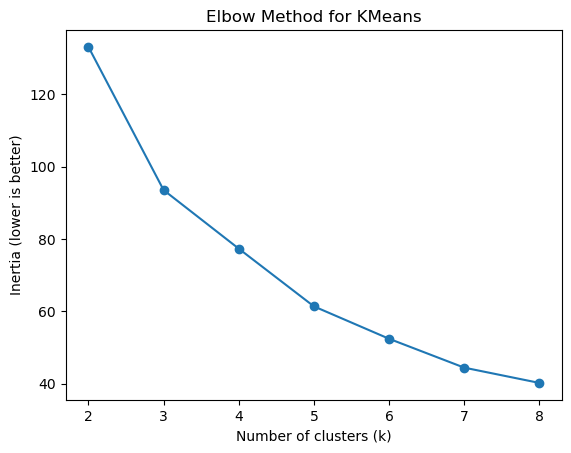

In [18]:
# Instantiate plot
plt.figure()

# plot number of clusters vs inertia
plt.plot(list(k_values), inertias, marker="o")

plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (lower is better)")

plt.xticks(list(k_values))
plt.show()

# Fit final KMeans model

In [19]:
K = 3 # number of clusters chosen from elbow method. Chosen based on "Where does improvement start slowing down?"

In [20]:
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
# random_state=42 is arbitrary seed. n_init=10 runs KMeans multiple times to prevent bad solution.

In [21]:
# assign each county to a cluster
county_features["cluster"] = kmeans.fit_predict(X_scaled)

In [22]:
county_features.head(10)

,fips,CTYNAME,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility,rdomestic_mig,cluster
0,12001,Alachua County,0.319704,-0.125115,0.064152,1.508141,0
1,12003,Baker County,0.369415,-0.153888,0.094209,8.162627,0
2,12005,Bay County,0.426789,-0.239428,0.108733,27.610062,2
3,12007,Bradford County,0.428973,-0.181912,0.090090,0.795386,0
4,12009,Brevard County,0.455545,-0.228420,0.111754,21.448371,2
5,12011,Broward County,0.367449,-0.160475,0.070096,-8.117224,0
6,12013,Calhoun County,0.403742,-0.110505,0.096958,-1.855791,0
7,12015,Charlotte County,0.589723,-0.357226,0.167312,37.271253,1
8,12017,Citrus County,0.536973,-0.246449,0.127848,36.801547,1
9,12019,Clay County,0.446206,-0.238076,0.117191,18.574376,2


# Summarize Clusters

In [23]:
# calculates the average value of each feature within each cluster.
cluster_summary = county_features.groupby("cluster")[features].mean()

In [24]:
cluster_summary

,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility,rdomestic_mig
cluster,,,,
0,0.387420,-0.139459,0.081357,7.436879
1,0.548253,-0.300801,0.144554,33.783586
2,0.468691,-0.216373,0.109527,18.843212


In [25]:
# How many counties per cluster
county_features["cluster"].value_counts()

cluster
0    26
2    26
1    15
Name: count, dtype: int64

In [26]:
# View counties within each cluster
for c in sorted(county_features["cluster"].unique()):
    counties = county_features[county_features["cluster"] == c]["CTYNAME"]
    print("\nCluster", c) # Add space for output clarity
    print(list(counties))


Cluster 0
['Alachua County', 'Baker County', 'Bradford County', 'Broward County', 'Calhoun County', 'Columbia County', 'Escambia County', 'Gadsden County', 'Gilchrist County', 'Hardee County', 'Holmes County', 'Jackson County', 'Jefferson County', 'Lafayette County', 'Leon County', 'Liberty County', 'Miami-Dade County', 'Okaloosa County', 'Okeechobee County', 'Orange County', 'Putnam County', 'Seminole County', 'Taylor County', 'Union County', 'Wakulla County', 'Washington County']

Cluster 1
['Charlotte County', 'Citrus County', 'Collier County', 'DeSoto County', 'Flagler County', 'Hernando County', 'Lee County', 'Manatee County', 'Marion County', 'Pasco County', 'St. Johns County', 'St. Lucie County', 'Sarasota County', 'Sumter County', 'Walton County']

Cluster 2
['Bay County', 'Brevard County', 'Clay County', 'Dixie County', 'Duval County', 'Franklin County', 'Glades County', 'Gulf County', 'Hamilton County', 'Hendry County', 'Highlands County', 'Hillsborough County', 'Indian Rive

### Cluster Interpretation

The clustering analysis identified three distinct housing market segments among Florida counties.

Cluster 0 – Stable markets  
Counties with relatively low domestic migration and lower volatility in home value growth.

Cluster 1 – Migration boom counties  
These counties experienced the highest migration rates and strongest housing appreciation during the 2020–2022 boom period.

Cluster 2 – Moderate growth markets  
Large metropolitan and suburban counties with moderate migration and steady housing growth.

# Visualize clusters

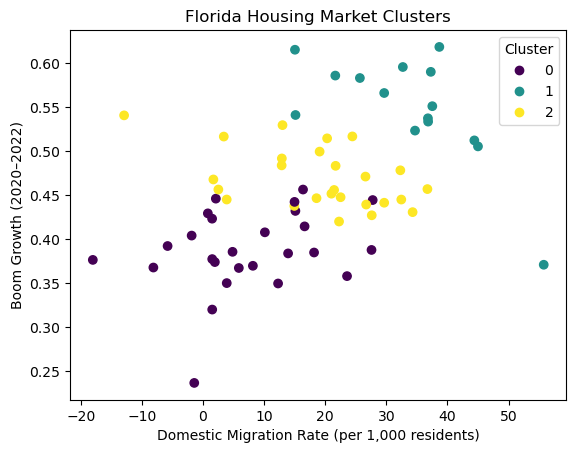

In [27]:
# create scatter plot
scatter = plt.scatter(
    county_features["rdomestic_mig"],
    county_features["boom_growth_2020_2022"],
    c=county_features["cluster"]
)

# label axes
plt.xlabel("Domestic Migration Rate (per 1,000 residents)")
plt.ylabel("Boom Growth (2020–2022)")

# chart title
plt.title("Florida Housing Market Clusters")

# add legend for clusters
plt.legend(*scatter.legend_elements(), title="Cluster")

# save image for visuals folder
plt.savefig("../visuals/housing_clusters_scatter.png")

plt.show()

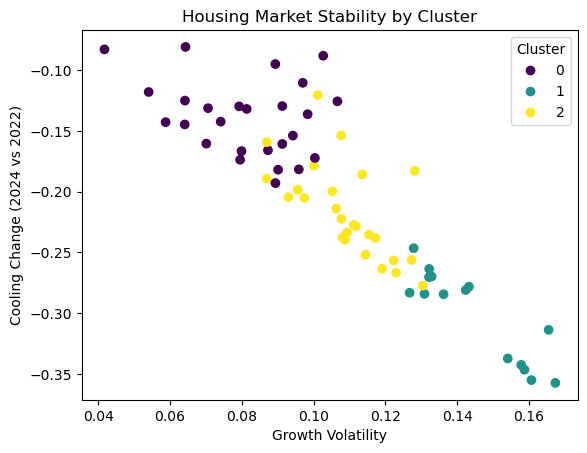

In [28]:
# Cluster stability visualization

scatter = plt.scatter(
    county_features["yoy_volatility"],
    county_features["cooling_delta_2024_vs_2022"],
    c=county_features["cluster"]
)

plt.xlabel("Growth Volatility")
plt.ylabel("Cooling Change (2024 vs 2022)")
plt.title("Housing Market Stability by Cluster")

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.savefig("../visuals/housing_clusters_stability.png")

plt.show()

# Add cluster labels to master dataset

In [29]:
# Add cluster labels
cluster_labels = {0: "Stable markets", 1: "Migration boom markets", 2: "Balanced growth markets"}

In [30]:
# Map cluster labels to county_features df
county_features["cluster_name"] = county_features["cluster"].map(cluster_labels)

In [31]:
# keep only the cluster columns from county_features
clusters = county_features[["fips", "cluster", "cluster_name"]]

In [32]:
# merge clusters into the full dataset
df_with_clusters = df.merge(clusters, on="fips", how="left")

In [33]:
df_with_clusters.head(50)

,fips,RegionName,year,zhvi_annual,STNAME,CTYNAME,domestic_mig,population,rdomestic_mig,yoy_growth,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility,cluster,cluster_name
0,12001,Alachua County,2020,213860.291033,Florida,Alachua County,1315,279765,NaN,NaN,0.319704,-0.125115,0.064152,0,Stable markets
1,12001,Alachua County,2021,244364.099887,Florida,Alachua County,1142,281710,4.067857,0.142634,0.319704,-0.125115,0.064152,0,Stable markets
2,12001,Alachua County,2022,282232.292655,Florida,Alachua County,1268,285241,4.473050,0.154966,0.319704,-0.125115,0.064152,0,Stable markets
3,12001,Alachua County,2023,295677.948240,Florida,Alachua County,408,288962,1.421100,0.047640,0.319704,-0.125115,0.064152,0,Stable markets
4,12001,Alachua County,2024,304504.265219,Florida,Alachua County,-1141,291782,-3.929442,0.029851,0.319704,-0.125115,0.064152,0,Stable markets
5,12003,Baker County,2020,214588.831681,Florida,Baker County,-141,28122,NaN,NaN,0.369415,-0.153888,0.094209,0,Stable markets
6,12003,Baker County,2021,250077.267178,Florida,Baker County,216,28378,7.646018,0.165379,0.369415,-0.153888,0.094209,0,Stable markets
7,12003,Baker County,2022,293861.137166,Florida,Baker County,-657,27781,-23.397853,0.175081,0.369415,-0.153888,0.094209,0,Stable markets
8,12003,Baker County,2023,292472.265114,Florida,Baker County,673,28542,23.897875,-0.004726,0.369415,-0.153888,0.094209,0,Stable markets
9,12003,Baker County,2024,298670.668188,Florida,Baker County,709,29325,24.504467,0.021193,0.369415,-0.153888,0.094209,0,Stable markets


# Exports

In [34]:
df_with_clusters.to_csv("../data/processed/merged_fl_county_year_clusters.csv",index=False)